## Carga y escalado de Datos


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Reshape, Multiply, Concatenate
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

# ==========================================
# 1. CARGA DE DATOS Y DESCARGA DE LA FED
# ==========================================
print("1. Cargando datos...")
df_ret = pd.read_csv('dataset_ia_log_returns_10y.csv', index_col=0, parse_dates=True)

# Calculamos Volatilidad (Multiparámetro)
df_vol = df_ret.rolling(window=21).std()

# Descargamos los tipos de la FED
fecha_inicio = df_ret.index.min()
fecha_fin = df_ret.index.max()
df_fed = web.DataReader('DFF', 'fred', fecha_inicio, fecha_fin)
df_fed.rename(columns={'DFF': 'Tipo_Interes_FED'}, inplace=True)
df_fed['Tipo_Interes_FED'] = df_fed['Tipo_Interes_FED'] / 100 # Formato decimal

# Unimos todo en un solo dataframe para asegurar que las fechas coinciden
df_master = df_ret.join(df_vol, rsuffix='_vol').join(df_fed, how='left')
df_master['Tipo_Interes_FED'] = df_master['Tipo_Interes_FED'].ffill() # Rellenar nulos de la FED
df_master = df_master.dropna() # Quitamos los 21 primeros días por la volatilidad

# Separar en Secuencial, Macro y Target (Y)
datos_secuenciales = df_master.drop(columns=['Tipo_Interes_FED']).values # Retornos + Volatilidades (24 cols)
datos_macro = df_master[['Tipo_Interes_FED']].values                     # FED (1 col)
datos_y = df_master.iloc[:, :12].values                                  # Solo los 12 Retornos para predecir

# ==========================================
# 2. ESCALADO (MinMaxScaler)
# ==========================================
print("2. Escalando datos...")
scaler_seq = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))

scaled_seq = scaler_seq.fit_transform(datos_secuenciales)
scaled_y = scaler_y.fit_transform(datos_y)
# La FED ya está en escala [0, ~0.10], la dejamos tal cual para no perder su significado real.

# ==========================================
# 3. CREACIÓN DE VENTANAS HÍBRIDAS
# ==========================================
print("3. Creando ventanas de tiempo...")
WINDOW_SIZE = 20
FORECAST_SIZE = 5

def create_hybrid_windows(data_seq, data_macro, data_y, window_size, forecast_size):
    X_seq, X_macro, y = [], [], []
    for i in range(len(data_seq) - window_size - forecast_size + 1):
        # 1. Secuencia de 20 días
        X_seq.append(data_seq[i:(i + window_size), :])
        # 2. Dato macro del DÍA ACTUAL (el último día de la ventana de 20)
        X_macro.append(data_macro[i + window_size - 1, :])
        # 3. Lo que queremos predecir (5 días futuros)
        y.append(data_y[(i + window_size):(i + window_size + forecast_size), :])
    return np.array(X_seq), np.array(X_macro), np.array(y)

X_seq, X_macro, y = create_hybrid_windows(scaled_seq, datos_macro, scaled_y, WINDOW_SIZE, FORECAST_SIZE)

# Split 80/20
split = int(0.8 * len(X_seq))
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
X_train_macro, X_test_macro = X_macro[:split], X_macro[split:]
y_train, y_test = y[:split], y[split:]

print(f" Forma X_train_seq (LSTM): {X_train_seq.shape}")
print(f" Forma X_train_macro (FED): {X_train_macro.shape}")

# ==========================================
# 4. CONSTRUCCIÓN DEL MODELO MULTI-INPUT
# ==========================================
print("4. Construyendo modelo híbrido...")
def attention_block(inputs):
    attention_probs = Dense(inputs.shape[-1], activation='softmax')(inputs)
    return Multiply()([inputs, attention_probs])

# --- RAMA 1: Secuencial (20 días, 24 variables) ---
input_seq = Input(shape=(WINDOW_SIZE, X_train_seq.shape[2]), name="Input_Secuencial")
lstm_1 = LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001))(input_seq)
dropout_1 = Dropout(0.2)(lstm_1)

attention = attention_block(dropout_1)

lstm_2 = LSTM(32, return_sequences=False, kernel_regularizer=l2(0.001))(attention)
rama_secuencial = Dropout(0.2)(lstm_2)

# --- RAMA 2: Macro (1 variable: FED) ---
input_macro = Input(shape=(1,), name="Input_Macro_FED")
rama_macro = Dense(8, activation='relu')(input_macro) # Le damos a la FED un peso en la red

# --- FUSIÓN (Concatenación) ---
fusion = Concatenate(name="Fusion_Capas")([rama_secuencial, rama_macro])

# Capas finales de decisión
densa_final = Dense(64, activation='relu')(fusion)
salida_cruda = Dense(FORECAST_SIZE * 12)(densa_final)
outputs = Reshape((FORECAST_SIZE, 12), name="Output_Prediccion")(salida_cruda)

# Compilamos
model_hibrido = Model(inputs=[input_seq, input_macro], outputs=outputs)
#model_hibrido.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_hibrido.compile(optimizer='adam', loss=tf.keras.losses.Huber(delta=1.0), metrics=['mae'])

# Generar y guardar la imagen del esquema (Busca el archivo 'esquema_modelo.png' en la carpeta de Colab)
plot_model(model_hibrido, to_file='esquema_modelo.png', show_shapes=True, show_layer_names=True, dpi=96)
print("✅ Esquema guardado como 'esquema_modelo.png'.")

# ==========================================
# 5. ENTRENAMIENTO
# ==========================================
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

print("\n--- Iniciando el Entrenamiento Híbrido ---")
# IMPORTANTE: Ahora pasamos una LISTA con los dos X_train
history = model_hibrido.fit(
    [X_train_seq, X_train_macro], y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

1. Cargando datos...
2. Escalando datos...
3. Creando ventanas de tiempo...
 Forma X_train_seq (LSTM): (1973, 20, 24)
 Forma X_train_macro (FED): (1973, 1)
4. Construyendo modelo híbrido...
✅ Esquema guardado como 'esquema_modelo.png'.

--- Iniciando el Entrenamiento Híbrido ---
Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.1111 - mae: 0.0993 - val_loss: 0.0475 - val_mae: 0.0720 - learning_rate: 0.0010
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0395 - mae: 0.0810 - val_loss: 0.0173 - val_mae: 0.0717 - learning_rate: 0.0010
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0163 - mae: 0.0809 - val_loss: 0.0084 - val_mae: 0.0718 - learning_rate: 0.0010
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0099 - mae: 0.0823 - val_loss: 0.0061 - val_mae: 0.0718 - learning_rate: 0.0010
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0083 - mae: 0.0825 - val_loss: 0.0056 - val_mae: 0.0719 - learning_rate: 0.0010
Epoch 6/10

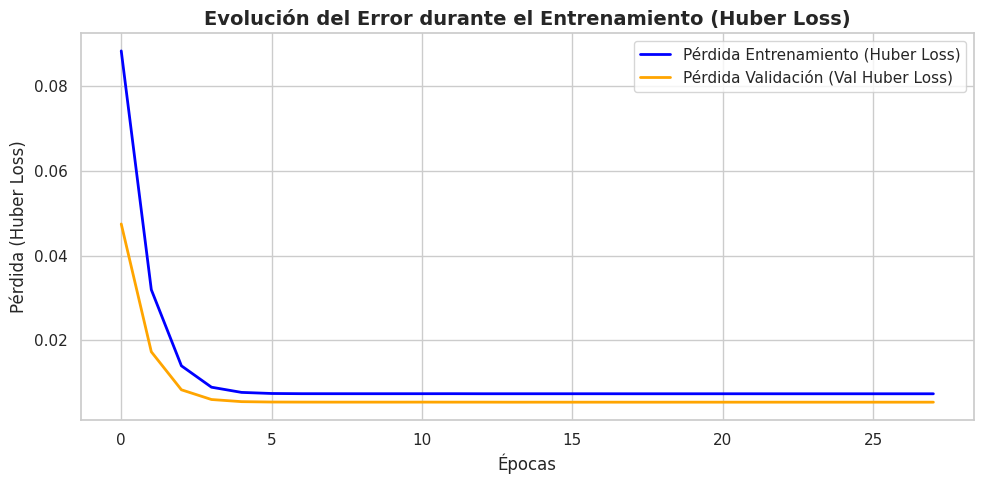

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo profesional para el TFG
sns.set_theme(style="whitegrid")

# --- 1. Gráfico de la Función de Pérdida (Huber Loss) ---
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Pérdida Entrenamiento (Huber Loss)', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Pérdida Validación (Val Huber Loss)', color='orange', linewidth=2)

plt.title('Evolución del Error durante el Entrenamiento (Huber Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Pérdida (Huber Loss)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("Calculando métricas para el Modelo Híbrido (LSTM + FED)...")

# 1. Generar predicciones con el conjunto de test HÍBRIDO (pasando las dos entradas)
y_pred_scaled = model_hibrido.predict([X_test_seq, X_test_macro])

# 2. Desnormalizar predicciones y valores reales
# Ahora y_pred_scaled y y_test tienen exactamente la misma dimensión (494, 5, 12)
y_pred_rescaled = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, num_assets)).reshape(y_test.shape)
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, num_assets)).reshape(y_test.shape)

# 3. Calcular RMSE y MAE globales
rmse_global = np.sqrt(mean_squared_error(y_test_rescaled.flatten(), y_pred_rescaled.flatten()))
mae_global = mean_absolute_error(y_test_rescaled.flatten(), y_pred_rescaled.flatten())

print(f"✅ RMSE Global (Escala Real): {rmse_global:.5f}")
print(f"✅ MAE Global (Escala Real): {mae_global:.5f}")

Calculando métricas para el Modelo Híbrido (LSTM + FED)...
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
✅ RMSE Global (Escala Real): 0.01736
✅ MAE Global (Escala Real): 0.01174


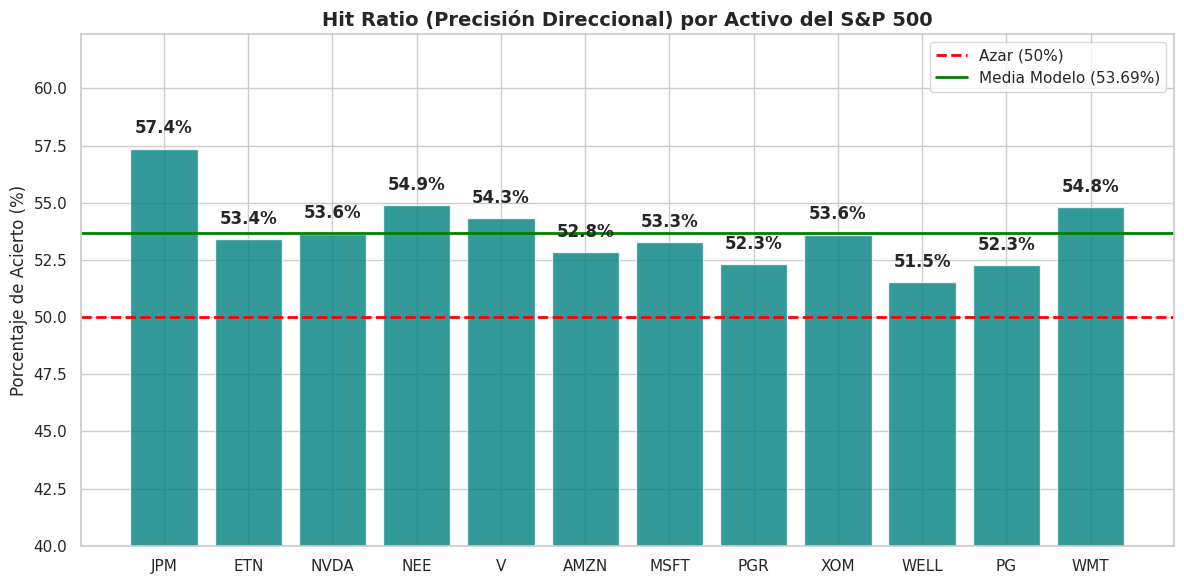

In [ ]:
# Hit ratio
# Calcular dirección (1 si es > 0, 0 si es <= 0)
dir_real = (y_test_rescaled > 0).astype(int)
dir_pred = (y_pred_rescaled > 0).astype(int)

hit_ratios = []
for i in range(num_assets):
    hr = accuracy_score(dir_real[:, :, i].flatten(), dir_pred[:, :, i].flatten())
    hit_ratios.append(hr * 100)

hr_promedio = np.mean(hit_ratios)

# Gráfico de Barras del Hit Ratio
plt.figure(figsize=(12, 6))
bars = plt.bar(df_ret.columns, hit_ratios, color='teal', alpha=0.8)
plt.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Azar (50%)')
plt.axhline(y=hr_promedio, color='green', linestyle='-', linewidth=2, label=f'Media Modelo ({hr_promedio:.2f}%)')

plt.title('Hit Ratio (Precisión Direccional) por Activo del S&P 500', fontsize=14, fontweight='bold')
plt.ylabel('Porcentaje de Acierto (%)', fontsize=12)
plt.ylim(40, max(hit_ratios) + 5) # Ajustamos el eje Y para ver mejor las diferencias
plt.legend(loc='upper right')

# Añadir las etiquetas encima de las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

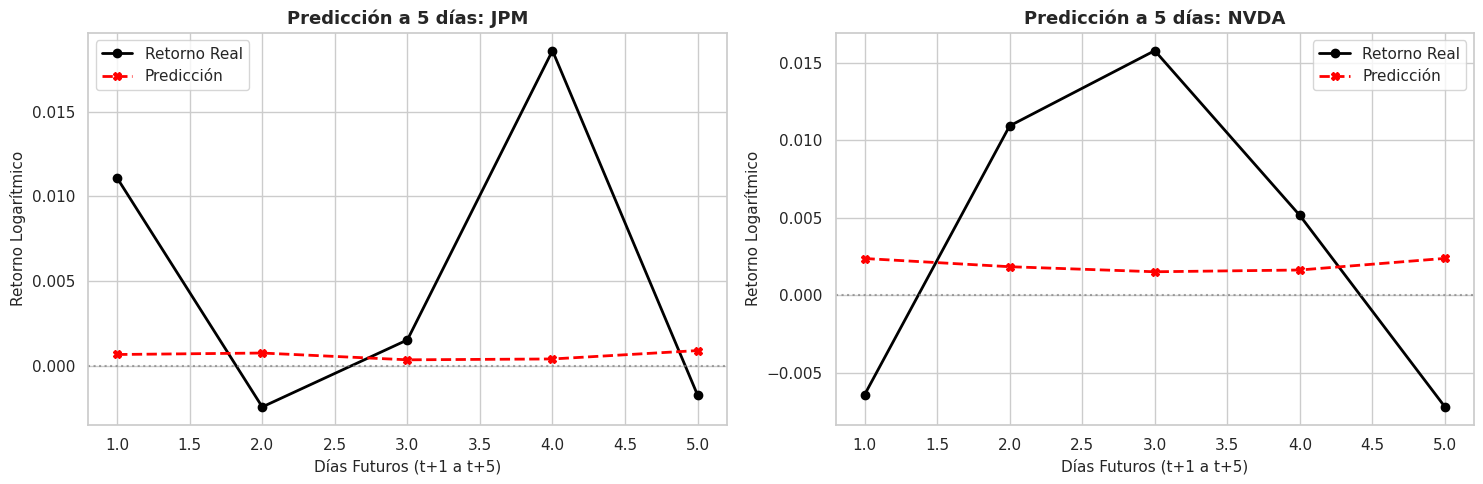

In [ ]:
# Comparativa visual
# Elegimos una muestra del conjunto de test (por ejemplo, la última muestra)
muestra_idx = -1
dias_futuros = range(1, 6)

# Activos a visualizar (0: JPM, 2: NVDA - Ajusta los índices según tus datos)
activos_plot = [0, 2]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, act_idx in enumerate(activos_plot):
    nombre_activo = df_ret.columns[act_idx]

    # Extraemos los 5 días reales y predichos
    real_5d = y_test_rescaled[muestra_idx, :, act_idx]
    pred_5d = y_pred_rescaled[muestra_idx, :, act_idx]

    axes[i].plot(dias_futuros, real_5d, marker='o', color='black', label='Retorno Real', linewidth=2)
    axes[i].plot(dias_futuros, pred_5d, marker='X', color='red', linestyle='--', label='Predicción', linewidth=2)

    axes[i].set_title(f'Predicción a 5 días: {nombre_activo}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Días Futuros (t+1 a t+5)', fontsize=11)
    axes[i].set_ylabel('Retorno Logarítmico', fontsize=11)
    axes[i].axhline(0, color='gray', linestyle=':', alpha=0.7) # Línea de retorno cero
    axes[i].legend()

plt.tight_layout()
plt.show()

1. Extrayendo predicciones de la IA...
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2. Calculando Riesgo y Tasa de la FED...
3. Ejecutando Optimización de Markowitz...

🎯 CARTERA ÓPTIMA DE MARKOWITZ GUIADA POR IA 🎯
--------------------------------------------------
Tasa de la FED (Libre de riesgo a 5 días): 0.072%
--------------------------------------------------
Activo  Retorno_Esperado_IA_5d (%)  Peso_Optimo (%)
    PG                       0.356            51.54
  NVDA                       0.978            29.56
   PGR                       0.403            14.44
  MSFT                       0.436             4.47


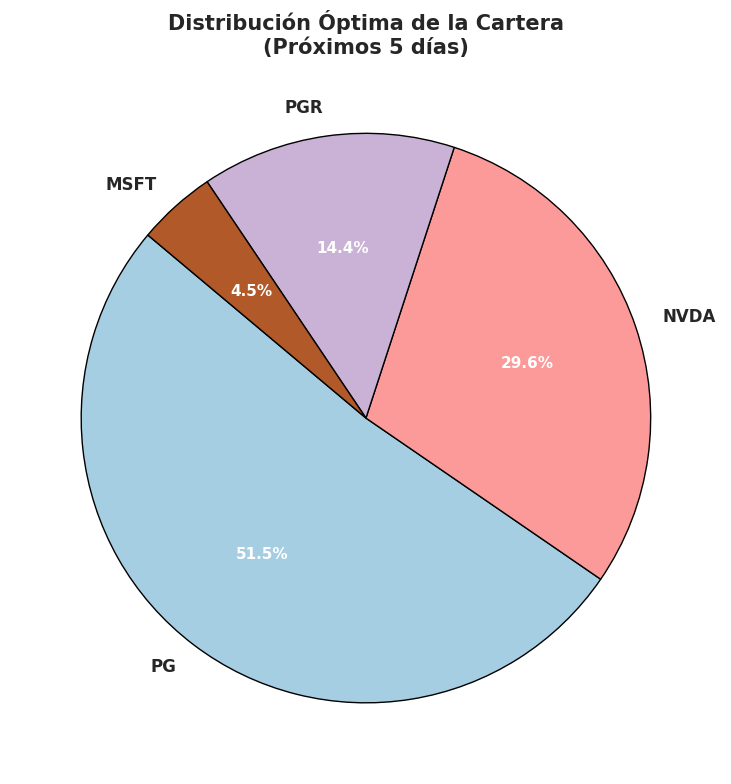

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

print("1. Extrayendo predicciones de la IA...")
# 1. Generar predicciones con el modelo híbrido (conjunto de test)
y_pred_scaled = model_hibrido.predict([X_test_seq, X_test_macro])

# 2. Desnormalizar para obtener retornos logarítmicos reales
y_pred_rescaled = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 12)).reshape(y_test.shape)

# 3. Tomar la ÚLTIMA predicción (simula estar en el "día de hoy" mirando al futuro)
prediccion_5_dias = y_pred_rescaled[-1] # Matriz de 5 días x 12 activos

# El retorno esperado a 5 días es la suma de los retornos diarios (propiedad aditiva de los log-returns)
retornos_esperados = np.sum(prediccion_5_dias, axis=0)
nombres_activos = df_master.columns[:12] # Los 12 tickers de tu dataset

print("2. Calculando Riesgo y Tasa de la FED...")
# 4. Matriz de Covarianza (Riesgo)
# Usamos los últimos 252 días hábiles (1 año) para medir cómo se correlacionan HOY los activos
datos_recientes = df_master.iloc[-252:, :12]
cov_matrix_diaria = datos_recientes.cov()
cov_matrix_5d = cov_matrix_diaria * 5 # Proyectamos la varianza diaria a 5 días

# 5. Tasa Libre de Riesgo (Risk-Free Rate)
# Tomamos el último dato de la FED conocido (que es anual) y lo pasamos a escala de 5 días
tasa_fed_anual = X_test_macro[-1][0]
rf_5d = (tasa_fed_anual / 252) * 5

print("3. Ejecutando Optimización de Markowitz...")
# 6. Función Objetivo (Maximizar Sharpe = Minimizar Sharpe Negativo)
def sharpe_negativo(pesos, retornos, covarianza, rf):
    retorno_cartera = np.sum(pesos * retornos)
    riesgo_cartera = np.sqrt(np.dot(pesos.T, np.dot(covarianza, pesos)))
    if riesgo_cartera == 0: return 1e5 # Penalización matemática para evitar divisiones por cero
    return -(retorno_cartera - rf) / riesgo_cartera

# 7. Restricciones del Optimizador
n_activos = len(nombres_activos)
restricciones = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1}) # El capital debe sumar 100% (1.0)
limites = tuple((0, 1) for _ in range(n_activos)) # No se permite vender en corto (pesos entre 0 y 1)
pesos_iniciales = np.array([1/n_activos] * n_activos) # Empezamos con una cartera equiponderada

# 8. Magia Matemática: Encontrar los pesos ideales
resultado = minimize(sharpe_negativo, pesos_iniciales,
                     args=(retornos_esperados, cov_matrix_5d.values, rf_5d),
                     method='SLSQP', bounds=limites, constraints=restricciones)

pesos_optimos = resultado.x

# ==========================================
# RESULTADOS Y GRÁFICAS
# ==========================================
df_cartera = pd.DataFrame({
    'Activo': nombres_activos,
    'Retorno_Esperado_IA_5d (%)': np.round(retornos_esperados * 100, 3),
    'Peso_Optimo (%)': np.round(pesos_optimos * 100, 2)
})

# Filtramos la "basura" matemática (activos con menos del 1% asignado)
df_filtrado = df_cartera[df_cartera['Peso_Optimo (%)'] > 1.0].sort_values(by='Peso_Optimo (%)', ascending=False)

print("\n🎯 CARTERA ÓPTIMA DE MARKOWITZ GUIADA POR IA 🎯")
print("-" * 50)
print(f"Tasa de la FED (Libre de riesgo a 5 días): {rf_5d*100:.3f}%")
print("-" * 50)
print(df_filtrado.to_string(index=False))



# Gráfico de la Cartera
plt.figure(figsize=(8, 8))
colores = plt.cm.Paired(np.linspace(0, 1, len(df_filtrado)))
wedges, texts, autotexts = plt.pie(df_filtrado['Peso_Optimo (%)'], labels=df_filtrado['Activo'],
                                   autopct='%1.1f%%', startangle=140, colors=colores,
                                   wedgeprops={'edgecolor': 'black', 'linewidth': 1})

plt.setp(autotexts, size=11, weight="bold", color="white")
plt.setp(texts, size=12, weight="bold")
plt.title('Distribución Óptima de la Cartera\n(Próximos 5 días)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()